<a href="https://colab.research.google.com/github/ali73/hands-on-mlp-exercise/blob/main/Chapter7/Ex07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# No. 09

In [7]:
from sklearn.model_selection import train_test_split

def load_and_split(X, Y, test_ratio=0.2, random_state = 42):
  X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    random_state=random_state,
    stratify=y
)
  return X_train, X_test, y_train, y_test

In [8]:
from sklearn.datasets import fetch_openml
# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# 70% train, 15% validation, 15% test
X_train, X_test, y_train, y_test = load_and_split(
    X,
    y,
    test_ratio=0.15
)

print(f"Train: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")

Train: 59500
Test: 10500


In [20]:
from sklearn.ensemble import RandomForestClassifier
import time

def train_random_forest(X, Y):


  # Create a Random Forest Classifier
  rf_classifier = RandomForestClassifier(random_state=42)
  print("Input shape is:", X.shape)

  print("Training Random Forest Classifier...")

  # Measure training time
  start_time = time.time()
  rf_classifier.fit(X, Y)
  end_time = time.time()

  training_time = end_time - start_time
  print(f"Random Forest Classifier trained successfully in {training_time:.2f} seconds.")
  return rf_classifier

rf_classifier = train_random_forest(X_train, y_train)

Input shape is: (59500, 784)
Training Random Forest Classifier...
Random Forest Classifier trained successfully in 59.18 seconds.


In [21]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, X_test, y_test):
  # Make predictions on the test set
  y_pred = model.predict(X_test)

  # Calculate accuracy
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Model Accuracy on Test Set: {accuracy:.4f}")


evaluate_model(rf_classifier, X_test, y_test)



Model Accuracy on Test Set: 0.9690


Now, use a PCA to reduce the dimension, and then re-train the model.

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)
#The number of components
pca.n_components_

np.int64(154)

In [23]:
rf_classifier = train_random_forest(X_reduced, y_train)

evaluate_model(rf_classifier, pca.transform(X_test), y_test)

Input shape is: (59500, 154)
Training Random Forest Classifier...
Random Forest Classifier trained successfully in 196.17 seconds.
Model Accuracy on Test Set: 0.9490


In [25]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import time

def train_sgd_classifier(X, Y, random_state=42):
  print(f"Input shape for SGDClassifier training: {X.shape}")
  sgd_clf = SGDClassifier(random_state=random_state)
  print("Training SGDClassifier...")
  start_time = time.time()
  sgd_clf.fit(X, Y)
  end_time = time.time()
  training_time = end_time - start_time
  print(f"SGDClassifier trained successfully in {training_time:.2f} seconds.")
  return sgd_clf

def evaluate_sgd_classifier(model, X_test, y_test):
  print("Evaluating SGDClassifier...")
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"SGDClassifier Accuracy on Test Set: {accuracy:.4f}")

In [28]:
sgd_clf = train_sgd_classifier(X_train, y_train)
evaluate_sgd_classifier(sgd_clf, X_test, y_test)

Input shape for SGDClassifier training: (59500, 784)
Training SGDClassifier...
SGDClassifier trained successfully in 237.50 seconds.
Evaluating SGDClassifier...
SGDClassifier Accuracy on Test Set: 0.8803


In [29]:
sgd_clf = train_sgd_classifier(X_reduced, y_train)
evaluate_sgd_classifier(sgd_clf, pca.transform(X_test), y_test)

Input shape for SGDClassifier training: (59500, 154)
Training SGDClassifier...
SGDClassifier trained successfully in 64.88 seconds.
Evaluating SGDClassifier...
SGDClassifier Accuracy on Test Set: 0.8784


# No. 10


Applying t-SNE to reduce dimensionality...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.015s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 1.767s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 567.846094
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.829330
[t-SNE] KL divergence after 1000 iterations: 1.459216
t-SNE dimensionality reduction complete.


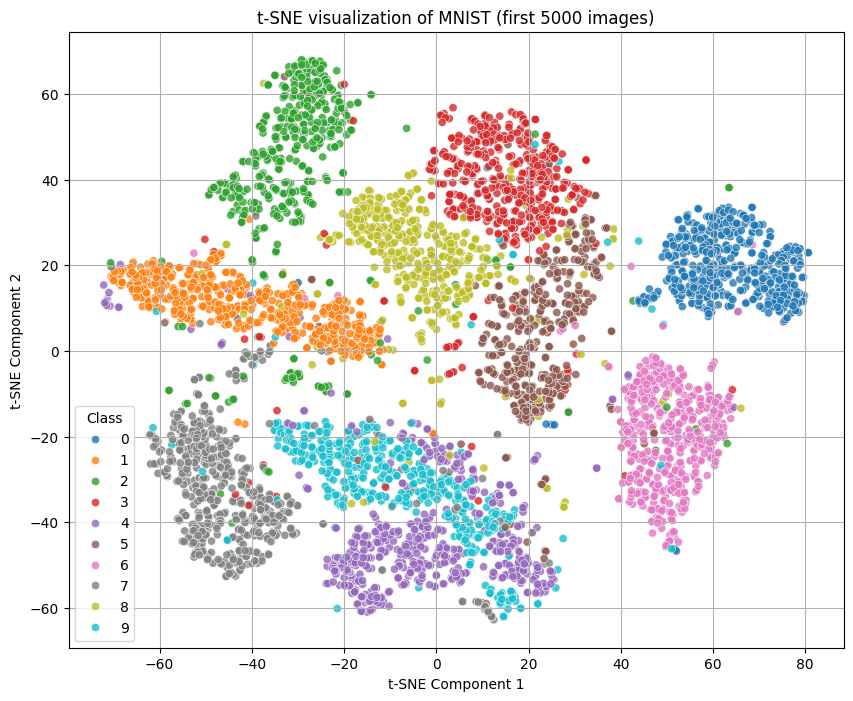

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use a subset of the data (first 5000 images)
X_subset = X[:5000]
y_subset = y[:5000]

# Initialize t-SNE with 2 components
# A smaller perplexity or fewer iterations might be needed for faster computation on larger datasets or if the default hangs.
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)

print("Applying t-SNE to reduce dimensionality...")
X_reduced_tsne = tsne.fit_transform(X_subset)
print("t-SNE dimensionality reduction complete.")

# Create a DataFrame for plotting
import pandas as pd
tsne_df = pd.DataFrame(data=X_reduced_tsne, columns=['TSNE-1', 'TSNE-2'])
tsne_df['Class'] = y_subset

# Plot the t-SNE reduced data
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE-1', y='TSNE-2',
    hue='Class',
    palette=sns.color_palette('tab10', len(np.unique(y_subset))),
    data=tsne_df,
    legend='full',
    alpha=0.8
)
plt.title('t-SNE visualization of MNIST (first 5000 images)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()